In [6]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

In [2]:
#import paths
db_dir, base_dir = get_user_config("shar")


[CONFIG] Using Shar's Darwin setup


In [3]:
#import metric and shared utils
metric, shared_utils = get_metric_and_su() #if this gives a UserWarning, run it again to clear

/lustre/lrspec/users/3155/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Loaded metric module: MDwarfFlares_metric
[INFO] Loaded shared_utils module


In [9]:
from MDwarf_config import *

In [20]:
#scientifically correct metric variables values live in MDwarf_config.py file and have been imported
#but you can adjust them here if you want to run tests

#adjusting rate density to be more manageable
rate_density = rate_density / 10**9


# Standardized output paths for this science case
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="MDwarfFlares", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths

MDwarfFlares_den_0.003880912272582138_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None


In [15]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Generating 1000 light curve templates.
Saved synthetic light curve templates to /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_3880912.272582138_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_templates.pkl
Loaded flare templates from /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_3880912.272582138_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_templates.pkl


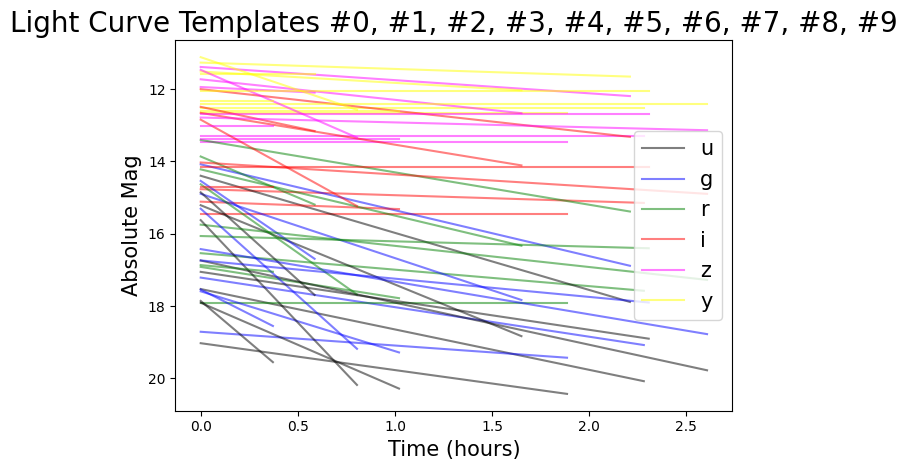

In [16]:
#plot light curves from pkl file if desired
# ylim = (20,17)
ylim=None
use_log_time = False
plot_overlap = True
plot_hours = True
shared_utils.plot_template_lcs(templates_file, num=10, use_log_time = use_log_time,plot_overlap=plot_overlap,ylim=ylim, plot_hours=plot_hours)

[INFO] Generating population and saving to /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_3880912.272582138_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_population.pkl
Simulated 4384 events using rate_density = 3.9e+06
Len ra before masking:  4384
b:  [ 31.42221553 -69.77132472 -42.30667511 ...  38.77339815  19.07187516
   4.95459961]
len mask, num true in mask:  4384 2202
len ra after masking:  2202


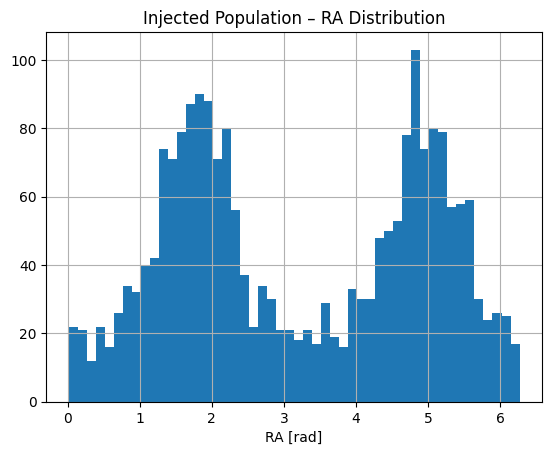

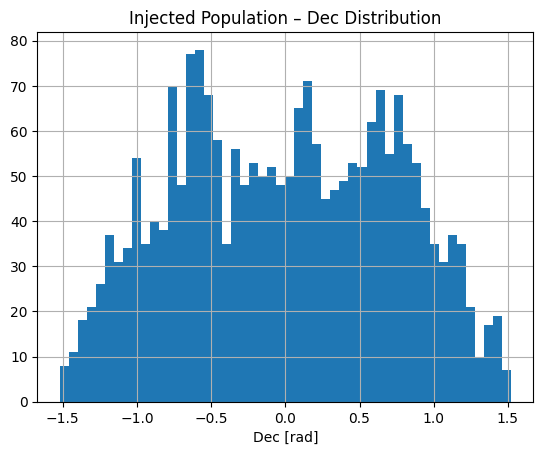

initial peak times:  [3267.65405184  679.99260697 1181.24374382 ... 2726.84011977   71.9125992
  998.20935923]
gal_lat_cut is none


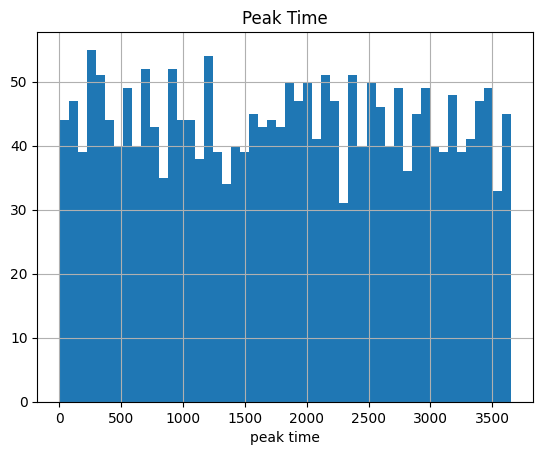

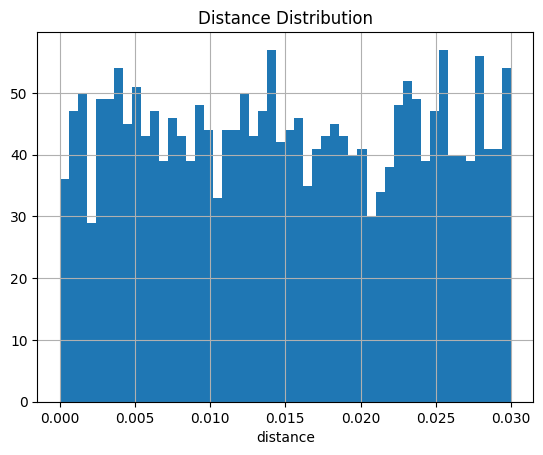

[DEBUG] coords.dec[:5]: [  7.18075578 -45.78396716 -23.31795707  36.42357364 -27.95318688] deg
[DEBUG] coords.dec.unit: deg


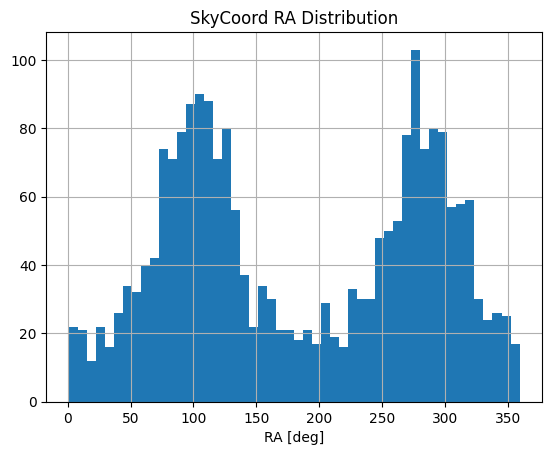

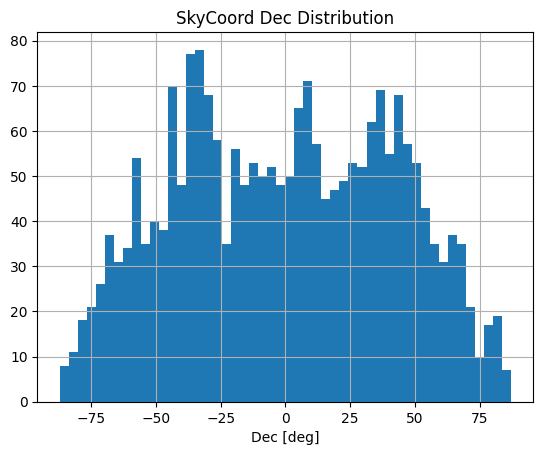

[INFO] Saved atomically to /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_3880912.272582138_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_population.pkl
DEBUG: type(peak_times) = <class 'numpy.ndarray'>
DEBUG: shape(peak_times) = (2202,)


In [17]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    lc_model=shared_lc_model,
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots
)


## All 10 years

In [13]:
#run detection metric
df_obs = shared_utils.run_detect(metric, 
                                 slicer, 
                                 cadences, 
                                 shared_lc_model, 
                                 db_dir, storage_dir, 
                                 df_file, 
                                 ignore_triples=ignore_triples, 
                                 debug=True, plot=True, 
                                 clean_temp=clean_temp,
                                 use_kcorrect=use_kcorrect,
                                 k_correct_type=None,
                                 k_correct_arg=None,
                                 use_extinction=use_extinction)


--- Running four_roll_v5.0.0_10yrs ---


KeyboardInterrupt: 

In [8]:

#choose what to run in run_multi_metrics
# we can remove historical if we want
# ,'silver','gold'
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=[ 'detect'], use_extinction=use_extinction)#, use_kcorrect=use_kcorrect, k_correct_type=None, k_correct_arg=None)


# Apply consistent diagnostics knobs
for m in multi_metrics:
    m.diag_store = False
    m.diag_sample_rate = 0.01
    m.diag_per_event_cap = 30
    m.diag_min_snr = 3
    m.diag_max_mag = None



In [ ]:
summary_df_bigger = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=False, clean_temp=clean_temp, use_extinction=use_extinction)


--- Running four_roll_v5.0.0_10yrs ---
(1,)


In [ ]:
summary_df_bigger

In [319]:



cols = ["sid",
        "injected_peak_ebv_mag_r",
        "injected_peak_ebv_mag_r_cadence",
        "eval_peak_mag"]
print(df_obs[cols].head())

print("Residuals vs cadence-aware (should ~0):",
      np.nanmedian(df_obs["eval_peak_mag"] - df_obs["injected_peak_ebv_mag_r_cadence"]))

print("Cadence penalty (cadence − global):",
      np.nanmedian(df_obs["injected_peak_ebv_mag_r_cadence"] - df_obs["injected_peak_ebv_mag_r"]))


   sid  injected_peak_ebv_mag_r  injected_peak_ebv_mag_r_cadence  \
0    0                33.283124                              NaN   
1    1                30.145389                              NaN   
2    2                34.265142                              NaN   
3    4                27.798796                              NaN   
4    5                34.182891                              NaN   

   eval_peak_mag  
0            NaN  
1            NaN  
2            NaN  
3            NaN  
4            NaN  
Residuals vs cadence-aware (should ~0): 0.0
Cadence penalty (cadence − global): 0.48632856095298393



--- Running four_roll_v5.0.0_10yrs ---
(1,)
                                      Sum                     run  \
four_roll_v5.0.0_10yrs_Detect_Metric  7.0  four_roll_v5.0.0_10yrs   

                                      n_events_full_sky  
four_roll_v5.0.0_10yrs_Detect_Metric             219137  


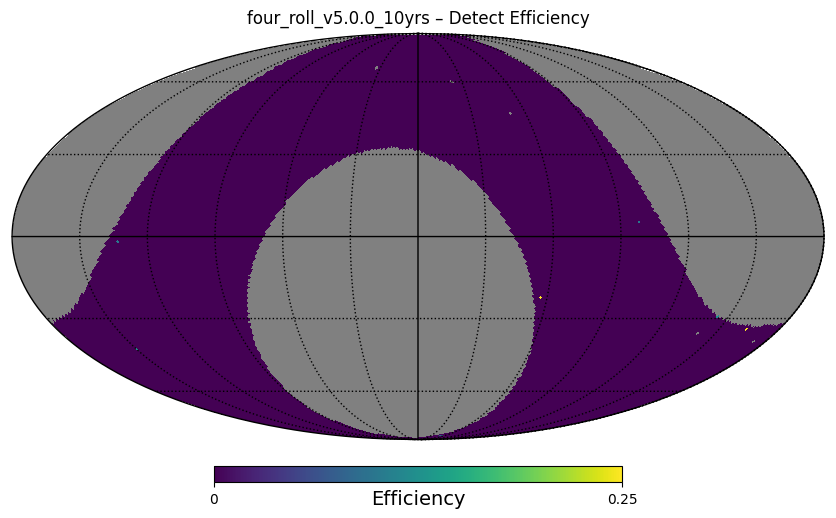

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v3.6_10yrs

--- Running baseline_v5.0.0_10yrs ---
(1,)


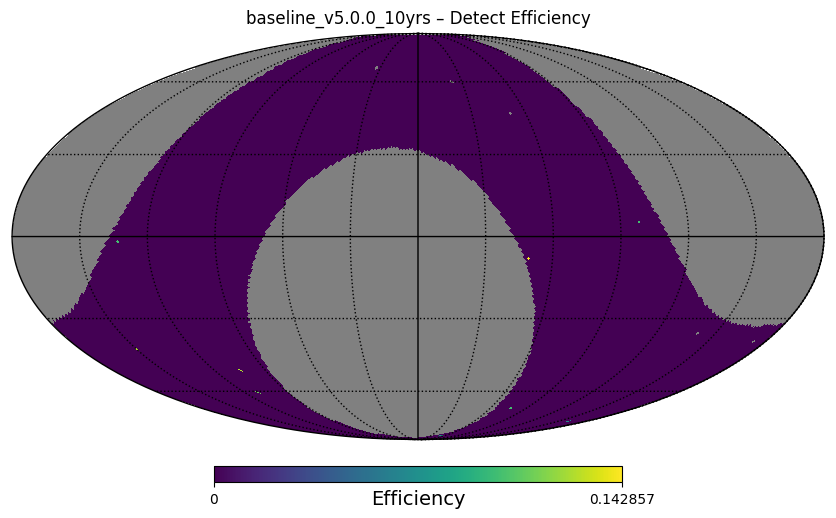

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v3.6_10yrs

--- Running noroll_v3.6_10yrs ---
(1,)


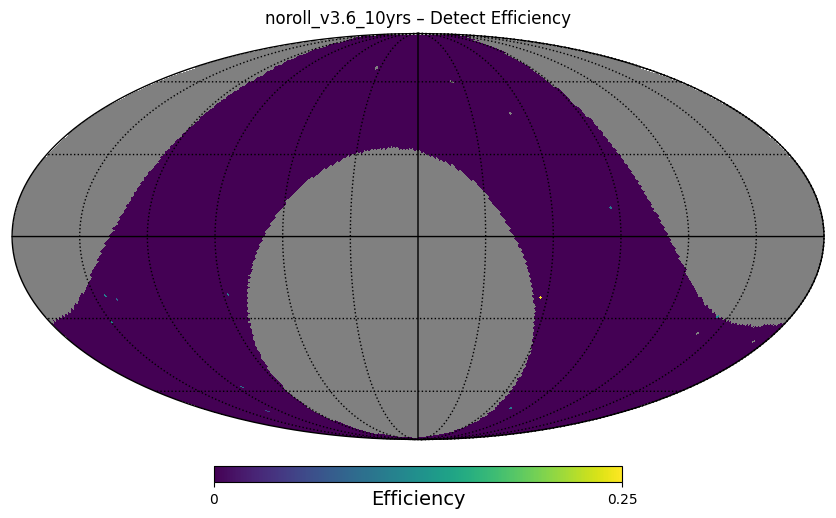

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v3.6_10yrs

--- Running baseline_v3.6_10yrs ---
(1,)


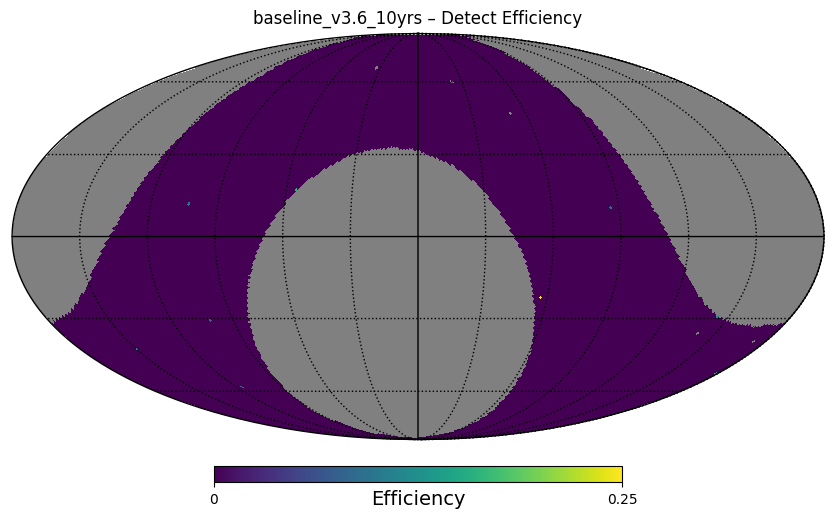

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v3.6_10yrs
saved summary to  /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_388091227.2582138_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_None_multi_summary.csv


In [25]:
summary_df = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [26]:
summary_df

,Sum,run,n_events_full_sky
four_roll_v5.0.0_10yrs_Detect_Metric,7.0,four_roll_v5.0.0_10yrs,219137
baseline_v5.0.0_10yrs_Detect_Metric,9.0,baseline_v5.0.0_10yrs,219137
noroll_v3.6_10yrs_Detect_Metric,10.0,noroll_v3.6_10yrs,219137
baseline_v3.6_10yrs_Detect_Metric,9.0,baseline_v3.6_10yrs,219137



--- Running four_roll_v4.3.1_10yrs ---
(3,)
[<local_MDwarfFlares_metric.Detect_Metric object at 0x721ebc650>, <local_MDwarfFlares_metric.MDwarfFlareSilverMetric object at 0x32b9d9490>, <local_MDwarfFlares_metric.MDwarfFlareGoldMetric object at 0xf82b85590>]
                                      Sum                     run  \
four_roll_v4.3.1_10yrs_Detect_Metric  7.0  four_roll_v4.3.1_10yrs   

                                      n_events_full_sky  
four_roll_v4.3.1_10yrs_Detect_Metric             380787  


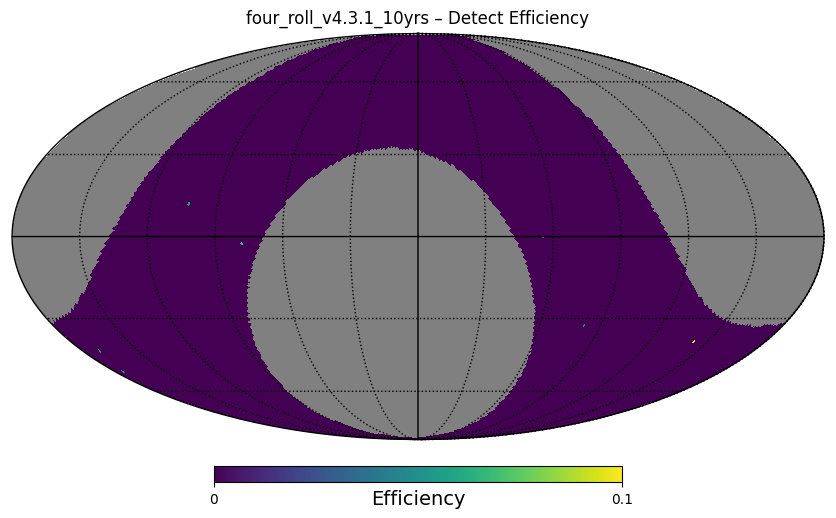

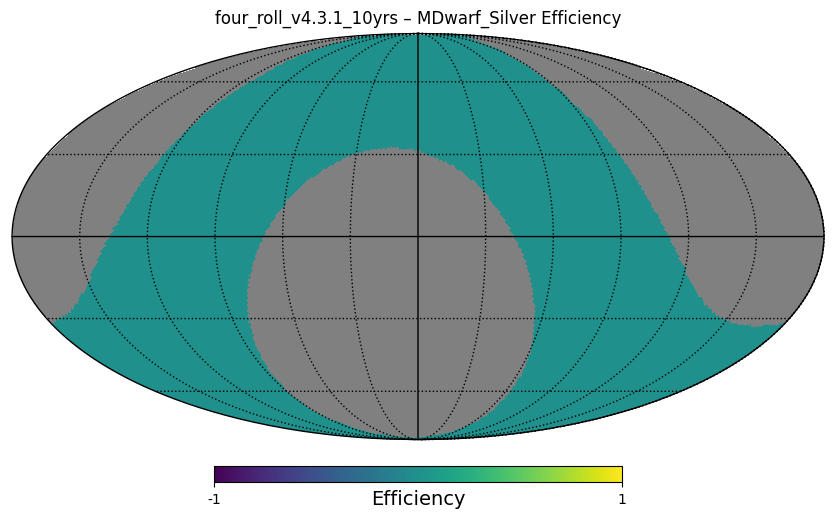

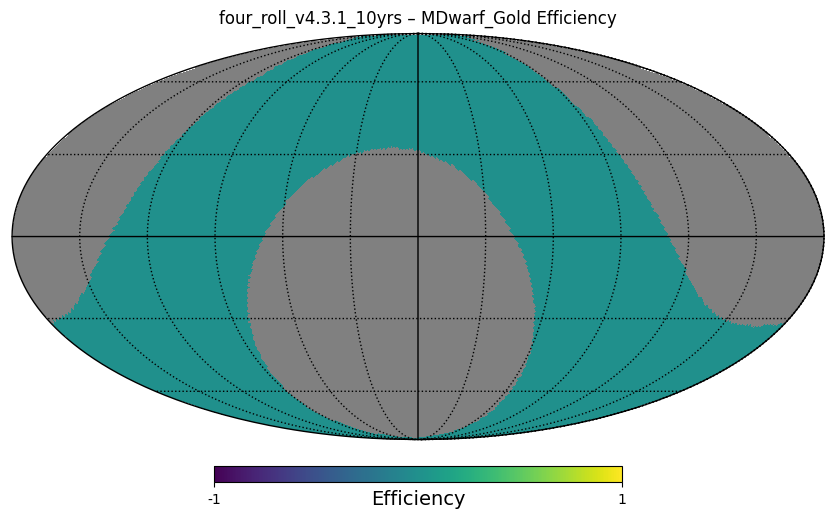

[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/Metric_temp_four_roll_v4.3.1_10yrs
saved summary to  /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_None_multi_summary.csv


In [321]:
summary_df_2 = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)


--- Running four_roll_v4.3.1_10yrs ---
(3,)
[<local_MDwarfFlares_metric.Detect_Metric object at 0x721ebc650>, <local_MDwarfFlares_metric.MDwarfFlareSilverMetric object at 0x32b9d9490>, <local_MDwarfFlares_metric.MDwarfFlareGoldMetric object at 0xf82b85590>]
                                      Sum                     run  \
four_roll_v4.3.1_10yrs_Detect_Metric  7.0  four_roll_v4.3.1_10yrs   

                                      n_events_full_sky  
four_roll_v4.3.1_10yrs_Detect_Metric             380787  


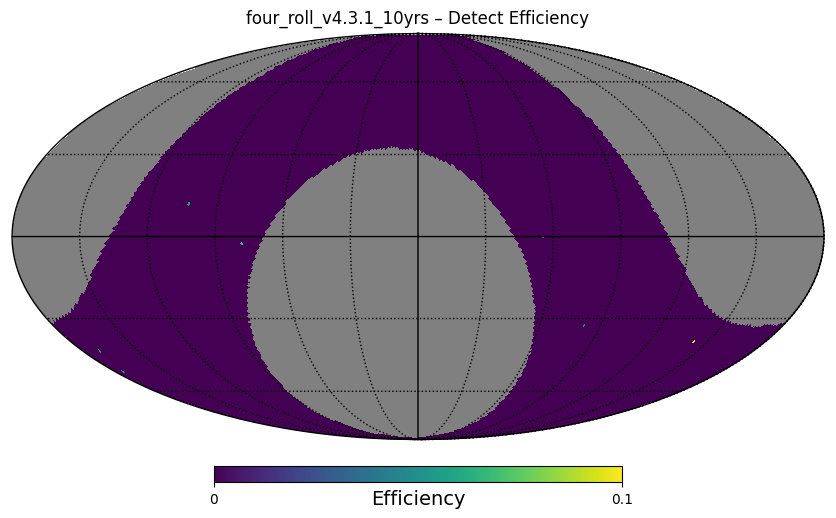

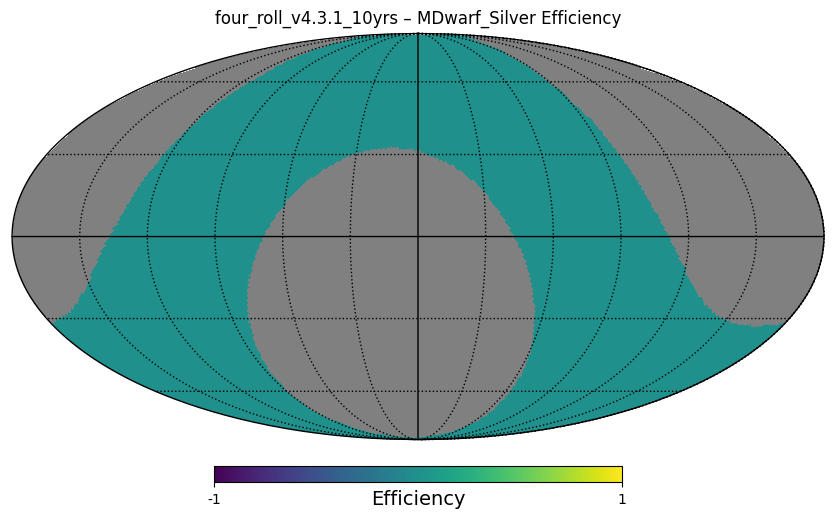

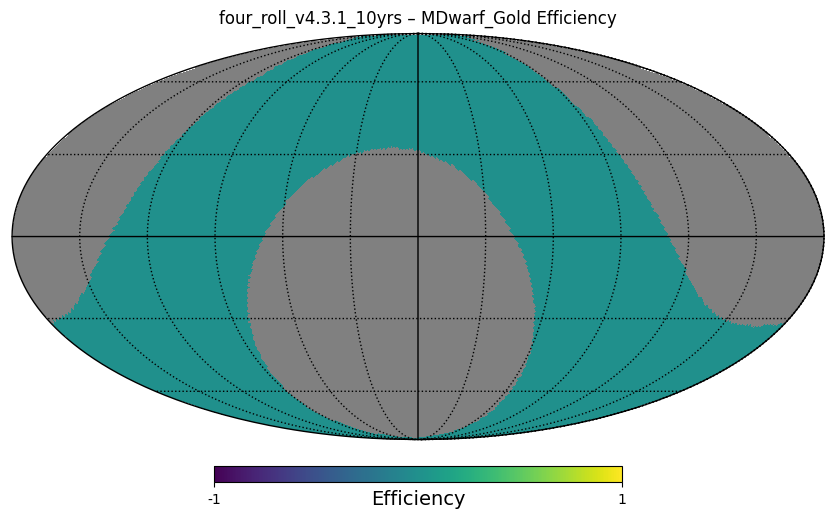

[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/Metric_temp_four_roll_v4.3.1_10yrs
saved summary to  /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_None_multi_summary.csv


In [322]:
summary_df_1 = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [323]:
summary_df_1

,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_Detect_Metric,7.0,four_roll_v4.3.1_10yrs,380787
four_roll_v4.3.1_10yrs_MDwarfFlareSilverMetric,0.0,four_roll_v4.3.1_10yrs,380787
four_roll_v4.3.1_10yrs_MDwarfFlareGoldMetric,0.0,four_roll_v4.3.1_10yrs,380787


In [325]:
import pickle
with open(pop_file, 'rb') as f:
    sp = pickle.load(f)
missing = [f'peak_app_mag_ebv_{f}' for f in ('u','g','r','i','z','y') if f'peak_app_mag_ebv_{f}' not in sp]
print("Missing peak columns:", missing or "None — all present")


Missing peak columns: None — all present


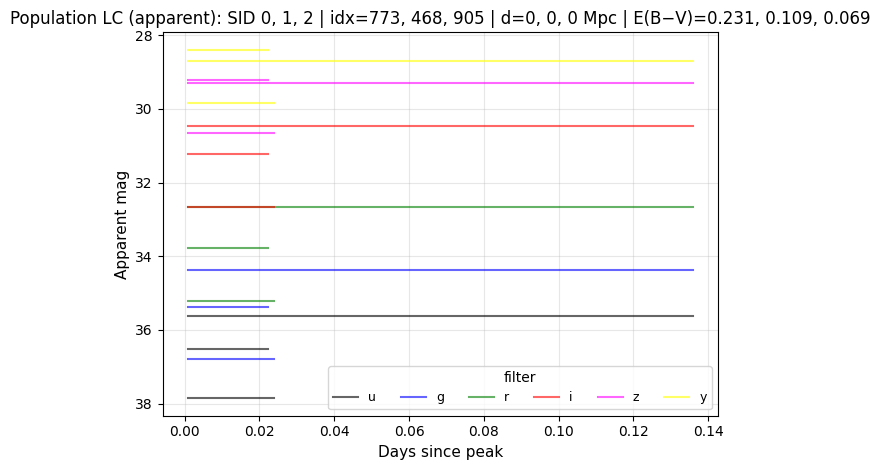

In [19]:
shared_utils.plot_population_lcs(
    pop_file=pop_file,
    lc_model=shared_lc_model,   # or pass templates_file=templates_file
    fast_peaks=False,
    use_kcorrect=use_kcorrect,
    k_correct_type=k_correct_type,
    k_correct_arg=k_correct_arg,
    num=3,
    days_before=0.0,            # see note below
    days_after=100.0,
    use_log_time=False,
    overlap=True
)
